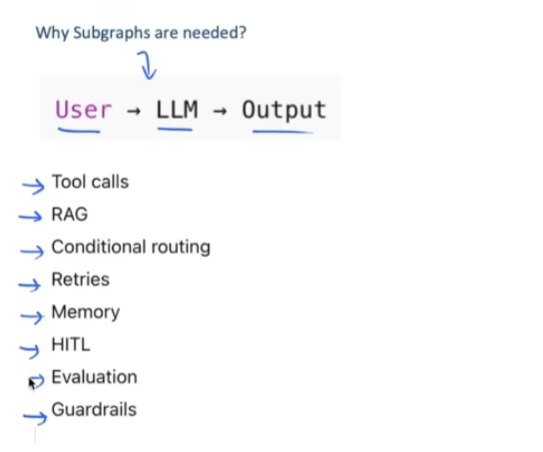

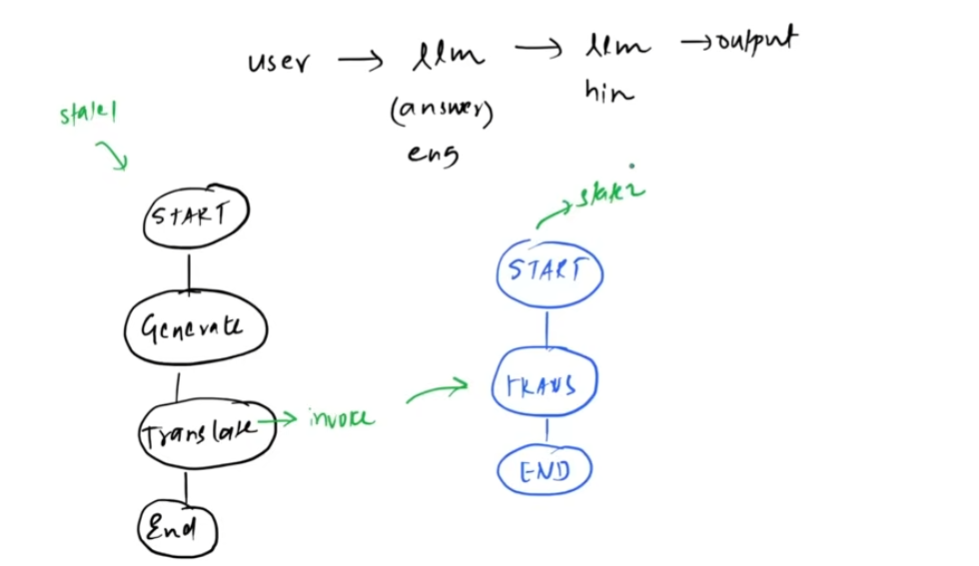

# Two different graph, and called subgraph in parent graph, different States

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from dotenv import load_dotenv

c:\Users\HP\Documents\Coding journeys\GenAI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [6]:
class SubState(TypedDict):
    input_text : str
    translated_text : str

In [7]:
subgraph_llm = ChatOllama(model="qwen3", temperature=0)

In [8]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [9]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [10]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [11]:
parent_llm = ChatOllama(model="qwen3", temperature=0)

In [12]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

def translate_answer(state: ParentState):
    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [13]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

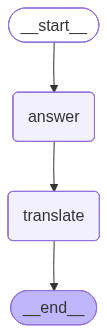

In [14]:
graph = parent_builder.compile()

graph

In [15]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics, or quantum mechanics, is a branch of physics that studies the behavior of matter and energy at the smallest scales—such as atoms, subatomic particles, and even fundamental particles like quarks. It describes how particles behave in ways that often defy classical intuition, introducing concepts like **superposition** (particles existing in multiple states at once), **entanglement** (particles being connected despite distance), and **wave-particle duality** (particles behaving as both waves and particles). \n\nKey principles include:\n- **Uncertainty Principle**: You cannot precisely measure certain pairs of properties (e.g., position and momentum) simultaneously.\n- **Quantization**: Energy and other properties come in discrete "quanta" (e.g., photons).\n- **Probabilistic Outcomes**: Experiments yield probabilities rather than definite results.\n\nQuantum physics underpins technologies like semiconductors, lasers, 

# The Shared Graph(Not translted to ollama check it out once)

In [16]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()

class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    
parent_llm = ChatOpenAI(model='gpt-4o-mini')
subgraph_llm = ChatOpenAI(model='gpt-4o')
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

graph = parent_builder.compile()

graph

graph.invoke({'question': 'What is quantum physics'})

OpenAIError: Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_KEY` environment variable.